# 02 - Construct Harmonization

## هدف نوت‌بوک

در این نوت‌بوک، سازه‌های مشترک بین Dataset B و Dataset EFL برای تحلیل بین‌دیتاستی هم‌تراز می‌شوند.

سازه‌های اصلی مشترک:

- Confirmation (CON)
- Satisfaction (SAT)
- Continuance Intention (CI)

مدل اصلی پژوهش:

CON + SAT → CI

Dataset B به‌عنوان Development Dataset و Dataset EFL به‌عنوان External Validation Dataset استفاده خواهد شد.

در این مرحله هیچ رکوردی صرفاً به دلیل Straight-line بودن حذف نمی‌شود و پرچم‌های کنترل کیفیت ایجادشده در Notebook 1 حفظ خواهند شد.

In [3]:
# در این سلول کتابخانه‌های موردنیاز و مسیر اصلی پروژه به‌صورت خودکار تعریف می‌شوند.

from pathlib import Path
import os
import pandas as pd
import numpy as np


# مسیر فعلی اجرای Notebook
CURRENT_DIR = Path.cwd().resolve()


# شناسایی خودکار ریشه پروژه
if CURRENT_DIR.name == "notebooks":

    PROJECT_ROOT = CURRENT_DIR.parent

elif (
    (CURRENT_DIR / "notebooks").exists()
    and (CURRENT_DIR / "data").exists()
):

    PROJECT_ROOT = CURRENT_DIR

else:

    raise FileNotFoundError(
        "Project root could not be detected. "
        "Please run this notebook from the project folder or the notebooks folder."
    )


PROCESSED_FOLDER = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed"
)

TABLES_FOLDER = os.path.join(
    PROJECT_ROOT,
    "outputs",
    "tables"
)


print("Project root:")
print(PROJECT_ROOT)

print("\nProcessed folder:")
print(PROCESSED_FOLDER)

print("\nTables folder:")
print(TABLES_FOLDER)


print("\nPath check:")
print("Processed folder exists:", os.path.exists(PROCESSED_FOLDER))
print("Tables folder exists:", os.path.exists(TABLES_FOLDER))

Project root:
F:\E_Learning_Continuance_ML

Processed folder:
F:\E_Learning_Continuance_ML\data\processed

Tables folder:
F:\E_Learning_Continuance_ML\outputs\tables

Path check:
Processed folder exists: True
Tables folder exists: True


In [4]:
# در این سلول فایل‌های موجود در پوشه processed بررسی می‌شوند تا خروجی‌های Notebook 1 شناسایی شوند.

print("Files inside processed folder:\n")

for file_name in os.listdir(PROCESSED_FOLDER):
    print(file_name)

Files inside processed folder:

dataset_B_model_ready.csv
dataset_B_processed.csv
dataset_B_quality_flagged.csv
dataset_EFL_quality_flagged.csv
dataset_EFL_sensitivity_filtered.csv


In [5]:
# در این سلول نسخه‌های Quality-Flagged دیتاست‌های B و EFL که در Notebook 1 ساخته شدند، بارگذاری می‌شوند.

file_B = os.path.join(
    PROCESSED_FOLDER,
    "dataset_B_quality_flagged.csv"
)

file_EFL = os.path.join(
    PROCESSED_FOLDER,
    "dataset_EFL_quality_flagged.csv"
)

df_B = pd.read_csv(file_B)
df_EFL = pd.read_csv(file_EFL)

print("Dataset B shape:", df_B.shape)
print("Dataset EFL shape:", df_EFL.shape)

print("\nDataset B columns:")
print(df_B.columns.tolist())

print("\nDataset EFL columns:")
print(df_EFL.columns.tolist())

Dataset B shape: (368, 30)
Dataset EFL shape: (435, 34)

Dataset B columns:
['index', 'totalseconds', 'Gender', 'Age', 'Grade', 'Subject', 'PEdS1', 'PEdS2', 'PEdS3', 'PEdS4', 'PEmS1', 'PEmS2', 'PEmS3', 'PEmS4', 'PU1', 'PU2', 'PU3', 'CON1', 'CON2', 'CON3', 'SAT1', 'SAT2', 'SAT3', 'CI1', 'CI2', 'CI3', 'Straight_Line_Flag', 'Very_Fast_Flag', 'High_Risk_Flag', 'Strict_Duplicate_Flag']

Dataset EFL columns:
['Gender', 'age', 'Grades', 'parentseducation', 'monthlyincome', 'PE1', 'PE2', 'PE3', 'PE4', 'PE5', 'PE6', 'PU1', 'PU2', 'PU3', 'PEOU1', 'PEOU2', 'PEOU3', 'SAT1', 'SAT2', 'SAT3', 'CI1', 'CI2', 'CI3', 'CON1', 'CON2', 'CON3', 'PE', 'PU', 'PEOU', 'SAT', 'CI', 'CON', 'Straight_Line_Flag', 'Exact_Duplicate_Flag']


In [6]:
# در این سلول امتیاز سه سازه مشترک CON، SAT و CI در هر دو دیتاست با میانگین آیتم‌های مربوطه محاسبه می‌شود.

# -------------------------
# Dataset B
# -------------------------

df_B["CON_score"] = df_B[
    ["CON1", "CON2", "CON3"]
].mean(axis=1)

df_B["SAT_score"] = df_B[
    ["SAT1", "SAT2", "SAT3"]
].mean(axis=1)

df_B["CI_score"] = df_B[
    ["CI1", "CI2", "CI3"]
].mean(axis=1)


# -------------------------
# Dataset EFL
# -------------------------

df_EFL["CON_score"] = df_EFL[
    ["CON1", "CON2", "CON3"]
].mean(axis=1)

df_EFL["SAT_score"] = df_EFL[
    ["SAT1", "SAT2", "SAT3"]
].mean(axis=1)

df_EFL["CI_score"] = df_EFL[
    ["CI1", "CI2", "CI3"]
].mean(axis=1)


print("Dataset B common construct scores:")
display(
    df_B[
        ["CON_score", "SAT_score", "CI_score"]
    ].head()
)

print("\nDataset EFL common construct scores:")
display(
    df_EFL[
        ["CON_score", "SAT_score", "CI_score"]
    ].head()
)

Dataset B common construct scores:


,CON_score,SAT_score,CI_score
0,4.333333,4.666667,5.000000
1,4.333333,4.333333,3.000000
2,3.333333,2.666667,2.666667
3,4.666667,5.000000,4.666667
4,2.000000,3.000000,3.333333



Dataset EFL common construct scores:


,CON_score,SAT_score,CI_score
0,4.333333,5.0,5.0
1,5.000000,5.0,5.0
2,5.000000,5.0,5.0
3,5.000000,5.0,5.0
4,5.000000,5.0,5.0


In [7]:
# در این سلول بازه، تعداد مقادیر گمشده و آمار اولیه امتیازهای مشترک در هر دو دیتاست بررسی می‌شود.

common_scores = [
    "CON_score",
    "SAT_score",
    "CI_score"
]

print("========== Dataset B ==========")

for column in common_scores:
    print(
        column,
        "| Min:", df_B[column].min(),
        "| Max:", df_B[column].max(),
        "| Missing:", df_B[column].isnull().sum()
    )

print("\nNumber of rows:", len(df_B))


print("\n========== Dataset EFL ==========")

for column in common_scores:
    print(
        column,
        "| Min:", df_EFL[column].min(),
        "| Max:", df_EFL[column].max(),
        "| Missing:", df_EFL[column].isnull().sum()
    )

print("\nNumber of rows:", len(df_EFL))

========== Dataset B ==========
CON_score | Min: 1.0 | Max: 5.0 | Missing: 0
SAT_score | Min: 1.0 | Max: 5.0 | Missing: 0
CI_score | Min: 1.0 | Max: 5.0 | Missing: 0

Number of rows: 368

========== Dataset EFL ==========
CON_score | Min: 1.6666666666666667 | Max: 5.0 | Missing: 0
SAT_score | Min: 1.6666666666666667 | Max: 5.0 | Missing: 0
CI_score | Min: 1.3333333333333333 | Max: 5.0 | Missing: 0

Number of rows: 435


In [8]:
# در این سلول بررسی می‌شود امتیازهای محاسبه‌شده ما با Compositeهای آماده موجود در Dataset EFL تطابق دارند یا خیر.

comparison_EFL = pd.DataFrame({
    "CON_difference": df_EFL["CON_score"] - df_EFL["CON"],
    "SAT_difference": df_EFL["SAT_score"] - df_EFL["SAT"],
    "CI_difference": df_EFL["CI_score"] - df_EFL["CI"]
})

print("Maximum absolute difference:")

print(
    comparison_EFL
    .abs()
    .max()
)

print("\nNumber of non-zero differences:")

print(
    (comparison_EFL.abs() > 1e-10)
    .sum()
)

Maximum absolute difference:
CON_difference    4.440892e-16
SAT_difference    4.440892e-16
CI_difference     4.440892e-16
dtype: float64

Number of non-zero differences:
CON_difference    0
SAT_difference    0
CI_difference     0
dtype: int64


In [9]:

# در این سلول نسخه‌های هم‌تراز Dataset B و Dataset EFL فقط با سازه‌های مشترک موردنیاز مدل اصلی ساخته می‌شوند.

df_B_core = df_B[
    [
        "CON_score",
        "SAT_score",
        "CI_score"
    ]
].copy()

df_EFL_core = df_EFL[
    [
        "CON_score",
        "SAT_score",
        "CI_score"
    ]
].copy()


# اضافه کردن نام دیتاست برای شناسایی منبع داده
df_B_core["Dataset"] = "B"
df_EFL_core["Dataset"] = "EFL"


# مرتب کردن ستون‌ها
column_order = [
    "Dataset",
    "CON_score",
    "SAT_score",
    "CI_score"
]

df_B_core = df_B_core[column_order]
df_EFL_core = df_EFL_core[column_order]


print("Dataset B Core shape:", df_B_core.shape)
display(df_B_core.head())

print("\nDataset EFL Core shape:", df_EFL_core.shape)


Dataset B Core shape: (368, 4)


,Dataset,CON_score,SAT_score,CI_score
0,B,4.333333,4.666667,5.000000
1,B,4.333333,4.333333,3.000000
2,B,3.333333,2.666667,2.666667
3,B,4.666667,5.000000,4.666667
4,B,2.000000,3.000000,3.333333



Dataset EFL Core shape: (435, 4)


In [10]:
# در این سلول میانگین، انحراف معیار، میانه، حداقل و حداکثر سه سازه مشترک بین Dataset B و Dataset EFL مقایسه می‌شوند.

constructs = [
    "CON_score",
    "SAT_score",
    "CI_score"
]

distribution_rows = []

for construct in constructs:

    distribution_rows.append({
        "Dataset": "B",
        "Construct": construct,
        "N": len(df_B_core),
        "Mean": df_B_core[construct].mean(),
        "Std": df_B_core[construct].std(),
        "Median": df_B_core[construct].median(),
        "Min": df_B_core[construct].min(),
        "Max": df_B_core[construct].max()
    })

    distribution_rows.append({
        "Dataset": "EFL",
        "Construct": construct,
        "N": len(df_EFL_core),
        "Mean": df_EFL_core[construct].mean(),
        "Std": df_EFL_core[construct].std(),
        "Median": df_EFL_core[construct].median(),
        "Min": df_EFL_core[construct].min(),
        "Max": df_EFL_core[construct].max()
    })


distribution_summary = pd.DataFrame(distribution_rows)

distribution_summary[
    ["Mean", "Std", "Median", "Min", "Max"]
] = distribution_summary[
    ["Mean", "Std", "Median", "Min", "Max"]
].round(3)

display(distribution_summary)

,Dataset,Construct,N,Mean,Std,Median,Min,Max
0,B,CON_score,368,3.822,0.857,4.0,1.000,5.0
1,EFL,CON_score,435,3.804,0.537,4.0,1.667,5.0
2,B,SAT_score,368,3.940,0.797,4.0,1.000,5.0
3,EFL,SAT_score,435,3.856,0.547,4.0,1.667,5.0
4,B,CI_score,368,3.959,0.782,4.0,1.000,5.0
5,EFL,CI_score,435,3.887,0.546,4.0,1.333,5.0


In [11]:
# در این سلول اختلاف استانداردشده میانگین سه سازه بین Dataset B و Dataset EFL محاسبه می‌شود.

smd_rows = []

for construct in constructs:

    mean_B = df_B_core[construct].mean()
    mean_EFL = df_EFL_core[construct].mean()

    std_B = df_B_core[construct].std()
    std_EFL = df_EFL_core[construct].std()

    n_B = len(df_B_core)
    n_EFL = len(df_EFL_core)

    pooled_std = np.sqrt(
        (
            ((n_B - 1) * std_B**2) +
            ((n_EFL - 1) * std_EFL**2)
        )
        /
        (n_B + n_EFL - 2)
    )

    smd = (mean_B - mean_EFL) / pooled_std

    smd_rows.append({
        "Construct": construct,
        "Mean_B": mean_B,
        "Mean_EFL": mean_EFL,
        "Mean_Difference": mean_B - mean_EFL,
        "Pooled_SD": pooled_std,
        "SMD": smd,
        "Absolute_SMD": abs(smd)
    })


smd_summary = pd.DataFrame(smd_rows)

smd_summary = smd_summary.round(3)

display(smd_summary)

,Construct,Mean_B,Mean_EFL,Mean_Difference,Pooled_SD,SMD,Absolute_SMD
0,CON_score,3.822,3.804,0.019,0.702,0.027,0.027
1,SAT_score,3.940,3.856,0.084,0.674,0.125,0.125
2,CI_score,3.959,3.887,0.072,0.664,0.108,0.108


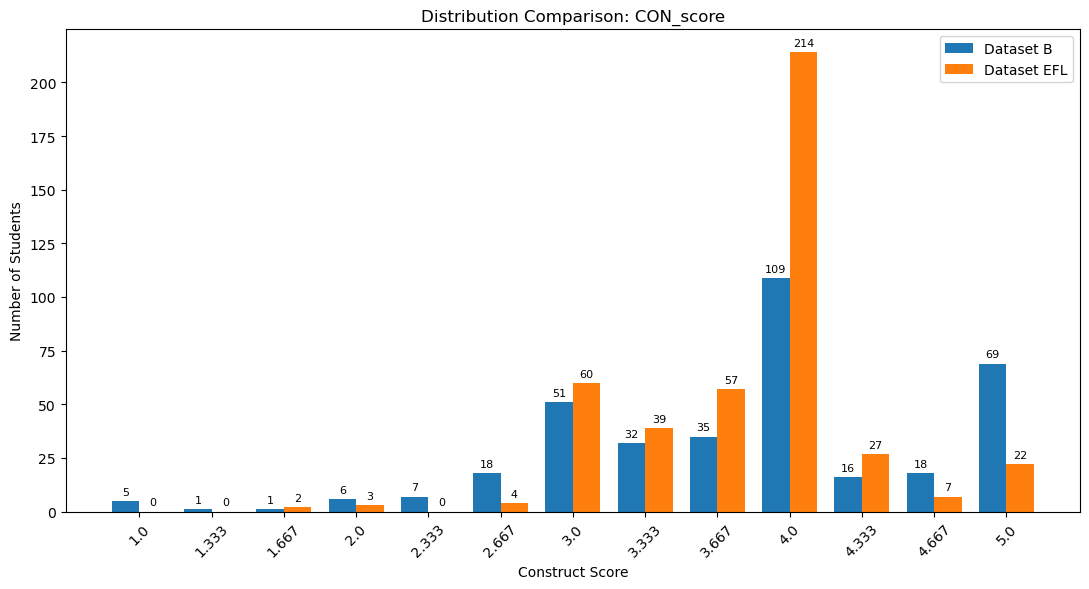

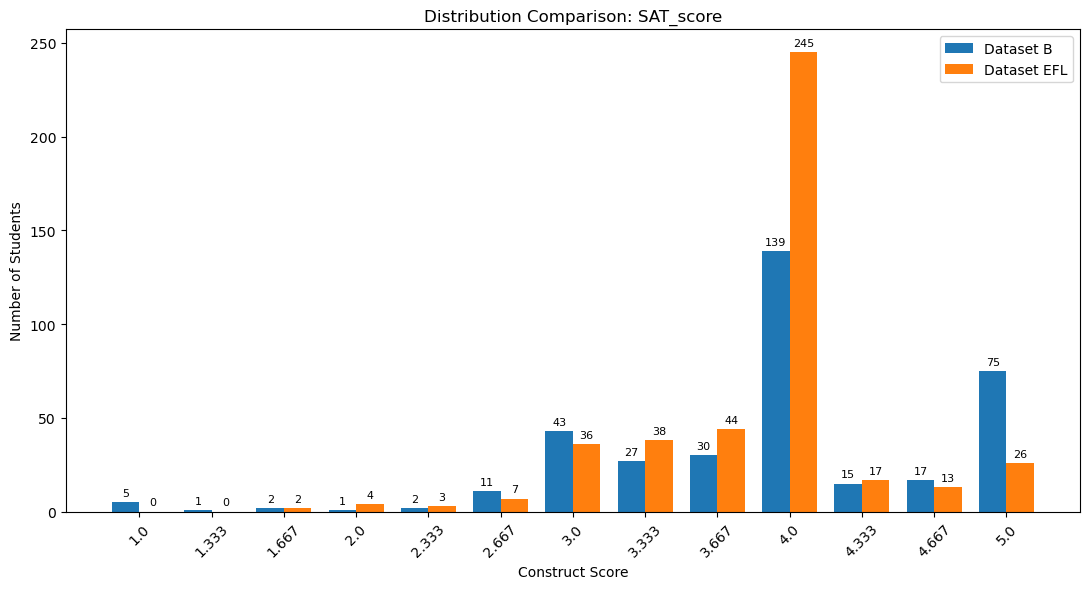

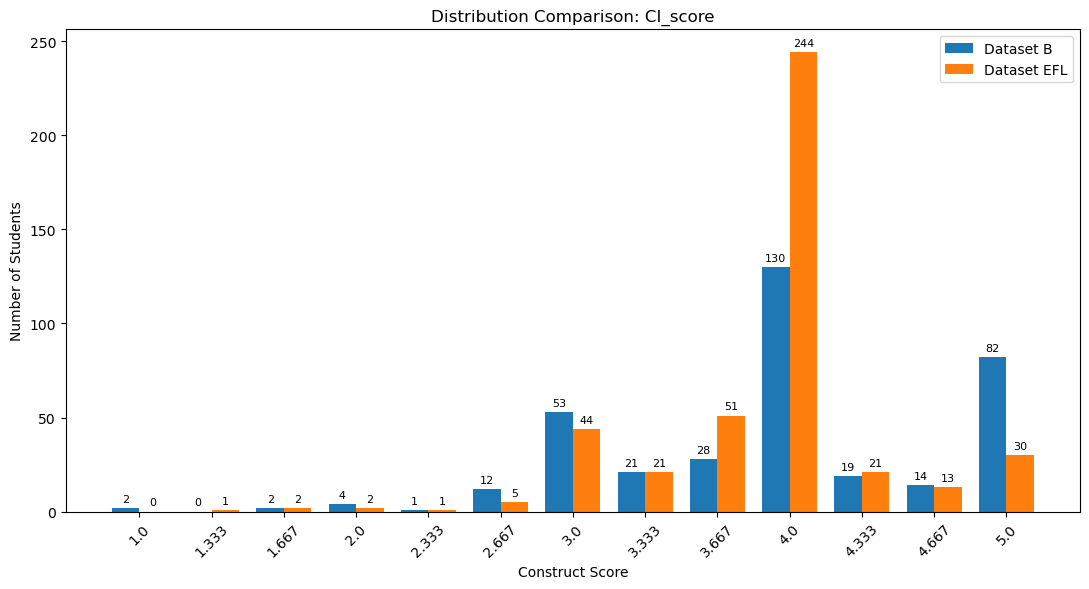

Saved files:
F:\E_Learning_Continuance_ML\outputs\figures\CON_score_Distribution_Comparison.png
F:\E_Learning_Continuance_ML\outputs\figures\SAT_score_Distribution_Comparison.png
F:\E_Learning_Continuance_ML\outputs\figures\CI_score_Distribution_Comparison.png


In [12]:
# در این سلول نمودارهای مقایسه توزیع سازه‌های مشترک نمایش داده و در پوشه figures ذخیره می‌شوند.

import os
import matplotlib.pyplot as plt

FIGURES_FOLDER = os.path.join(
    PROJECT_ROOT,
    "outputs",
    "figures"
)

os.makedirs(FIGURES_FOLDER, exist_ok=True)

saved_files = []

for construct in constructs:

    # تعداد هر مقدار امتیاز در Dataset B
    counts_B = (
        df_B_core[construct]
        .round(3)
        .value_counts()
        .sort_index()
    )

    # تعداد هر مقدار امتیاز در Dataset EFL
    counts_EFL = (
        df_EFL_core[construct]
        .round(3)
        .value_counts()
        .sort_index()
    )

    # همه امتیازهای موجود در دو دیتاست
    all_scores = sorted(
        set(counts_B.index) | set(counts_EFL.index)
    )

    values_B = [counts_B.get(score, 0) for score in all_scores]
    values_EFL = [counts_EFL.get(score, 0) for score in all_scores]

    x = np.arange(len(all_scores))
    width = 0.38

    fig, ax = plt.subplots(figsize=(11, 6))

    bars_B = ax.bar(
        x - width / 2,
        values_B,
        width,
        label="Dataset B"
    )

    bars_EFL = ax.bar(
        x + width / 2,
        values_EFL,
        width,
        label="Dataset EFL"
    )

    ax.bar_label(
        bars_B,
        padding=3,
        fontsize=8
    )

    ax.bar_label(
        bars_EFL,
        padding=3,
        fontsize=8
    )

    ax.set_xlabel("Construct Score")
    ax.set_ylabel("Number of Students")
    ax.set_title(f"Distribution Comparison: {construct}")
    ax.set_xticks(x)
    ax.set_xticklabels(all_scores, rotation=45)
    ax.legend()

    plt.tight_layout()

    file_path = os.path.join(
        FIGURES_FOLDER,
        f"{construct}_Distribution_Comparison.png"
    )

    plt.savefig(
        file_path,
        dpi=300,
        bbox_inches="tight"
    )

    saved_files.append(file_path)

    plt.show()
    plt.close()

print("Saved files:")
for file in saved_files:
    print(file)

In [13]:
# در این سلول همبستگی بین CON، SAT و CI در Dataset B و Dataset EFL محاسبه و مقایسه می‌شود.

core_constructs = [
    "CON_score",
    "SAT_score",
    "CI_score"
]

# ماتریس همبستگی Dataset B
correlation_B = (
    df_B_core[core_constructs]
    .corr()
    .round(3)
)

# ماتریس همبستگی Dataset EFL
correlation_EFL = (
    df_EFL_core[core_constructs]
    .corr()
    .round(3)
)

print("Correlation Matrix - Dataset B:")
display(correlation_B)

print("\nCorrelation Matrix - Dataset EFL:")
display(correlation_EFL)

Correlation Matrix - Dataset B:


,CON_score,SAT_score,CI_score
CON_score,1.000,0.815,0.703
SAT_score,0.815,1.000,0.776
CI_score,0.703,0.776,1.000



Correlation Matrix - Dataset EFL:


,CON_score,SAT_score,CI_score
CON_score,1.000,0.711,0.707
SAT_score,0.711,1.000,0.718
CI_score,0.707,0.718,1.000


In [14]:
# در این سلول تفاوت همبستگی‌های CON، SAT و CI بین دو دیتاست با آزمون Fisher r-to-z بررسی می‌شود.

from scipy.stats import norm
import numpy as np
import pandas as pd

correlation_pairs = [
    ("CON_score", "SAT_score"),
    ("CON_score", "CI_score"),
    ("SAT_score", "CI_score")
]

correlation_comparison = []

n_B = len(df_B_core)
n_EFL = len(df_EFL_core)

for var1, var2 in correlation_pairs:

    r_B = df_B_core[var1].corr(df_B_core[var2])
    r_EFL = df_EFL_core[var1].corr(df_EFL_core[var2])

    # تبدیل Fisher z
    z_B = np.arctanh(r_B)
    z_EFL = np.arctanh(r_EFL)

    # خطای استاندارد اختلاف
    standard_error = np.sqrt(
        (1 / (n_B - 3)) +
        (1 / (n_EFL - 3))
    )

    # آماره z
    z_difference = (
        z_B - z_EFL
    ) / standard_error

    # مقدار p دوطرفه
    p_value = 2 * (
        1 - norm.cdf(abs(z_difference))
    )

    correlation_comparison.append({
        "Relationship": f"{var1} ↔ {var2}",
        "r_B": r_B,
        "r_EFL": r_EFL,
        "Absolute_Difference": abs(r_B - r_EFL),
        "Fisher_Z": z_difference,
        "P_Value": p_value
    })


correlation_comparison = pd.DataFrame(
    correlation_comparison
)

correlation_comparison[
    [
        "r_B",
        "r_EFL",
        "Absolute_Difference",
        "Fisher_Z",
        "P_Value"
    ]
] = correlation_comparison[
    [
        "r_B",
        "r_EFL",
        "Absolute_Difference",
        "Fisher_Z",
        "P_Value"
    ]
].round(4)

display(correlation_comparison)

,Relationship,r_B,r_EFL,Absolute_Difference,Fisher_Z,P_Value
0,CON_score ↔ SAT_score,0.8151,0.7112,0.1038,3.5481,0.0004
1,CON_score ↔ CI_score,0.7032,0.7075,0.0043,-0.1190,0.9053
2,SAT_score ↔ CI_score,0.7763,0.7176,0.0587,1.8746,0.0608


In [15]:
# در این سلول نتایج اصلی هم‌ترازی سازه‌ها بین Dataset B و Dataset EFL در یک جدول نهایی جمع‌بندی می‌شوند.

harmonization_evidence = pd.DataFrame({

    "Construct": [
        "CON",
        "SAT",
        "CI"
    ],

    "Role": [
        "Predictor",
        "Predictor",
        "Target"
    ],

    "Mean_B": [
        df_B_core["CON_score"].mean(),
        df_B_core["SAT_score"].mean(),
        df_B_core["CI_score"].mean()
    ],

    "Mean_EFL": [
        df_EFL_core["CON_score"].mean(),
        df_EFL_core["SAT_score"].mean(),
        df_EFL_core["CI_score"].mean()
    ],

    "Absolute_SMD": [
        smd_summary.loc[
            smd_summary["Construct"] == "CON_score",
            "Absolute_SMD"
        ].iloc[0],

        smd_summary.loc[
            smd_summary["Construct"] == "SAT_score",
            "Absolute_SMD"
        ].iloc[0],

        smd_summary.loc[
            smd_summary["Construct"] == "CI_score",
            "Absolute_SMD"
        ].iloc[0]
    ],

    "Semantic_Compatibility": [
        "Good",
        "Very High",
        "Very High"
    ],

    "Cross_Dataset_Use": [
        "Yes",
        "Yes",
        "Yes"
    ]
})

harmonization_evidence[
    ["Mean_B", "Mean_EFL", "Absolute_SMD"]
] = harmonization_evidence[
    ["Mean_B", "Mean_EFL", "Absolute_SMD"]
].round(3)

display(harmonization_evidence)

,Construct,Role,Mean_B,Mean_EFL,Absolute_SMD,Semantic_Compatibility,Cross_Dataset_Use
0,CON,Predictor,3.822,3.804,0.027,Good,Yes
1,SAT,Predictor,3.940,3.856,0.125,Very High,Yes
2,CI,Target,3.959,3.887,0.108,Very High,Yes


In [16]:
# در این سلول جدول‌های اصلی Harmonization و مقایسه بین Dataset B و Dataset EFL ذخیره می‌شوند.

distribution_summary.to_excel(
    os.path.join(
        TABLES_FOLDER,
        "B_EFL_Distribution_Summary.xlsx"
    ),
    index=False
)

smd_summary.to_excel(
    os.path.join(
        TABLES_FOLDER,
        "B_EFL_SMD_Summary.xlsx"
    ),
    index=False
)

correlation_comparison.to_excel(
    os.path.join(
        TABLES_FOLDER,
        "B_EFL_Correlation_Comparison.xlsx"
    ),
    index=False
)

harmonization_evidence.to_excel(
    os.path.join(
        TABLES_FOLDER,
        "B_EFL_Final_Harmonization_Evidence.xlsx"
    ),
    index=False
)

print("Harmonization tables saved successfully.")

Harmonization tables saved successfully.


In [17]:
# در این سلول نسخه‌های نهایی Model-Ready برای توسعه مدل و اعتبارسنجی خارجی ساخته می‌شوند.

model_ready_B = df_B[
    [
        "CON_score",
        "SAT_score",
        "CI_score",
        "Straight_Line_Flag",
        "Very_Fast_Flag",
        "High_Risk_Flag",
        "Strict_Duplicate_Flag"
    ]
].copy()

model_ready_EFL = df_EFL[
    [
        "CON_score",
        "SAT_score",
        "CI_score",
        "Straight_Line_Flag",
        "Exact_Duplicate_Flag"
    ]
].copy()

model_ready_B["Dataset"] = "B"
model_ready_EFL["Dataset"] = "EFL"

model_ready_B = model_ready_B[
    [
        "Dataset",
        "CON_score",
        "SAT_score",
        "CI_score",
        "Straight_Line_Flag",
        "Very_Fast_Flag",
        "High_Risk_Flag",
        "Strict_Duplicate_Flag"
    ]
]

model_ready_EFL = model_ready_EFL[
    [
        "Dataset",
        "CON_score",
        "SAT_score",
        "CI_score",
        "Straight_Line_Flag",
        "Exact_Duplicate_Flag"
    ]
]

print("Model-ready Dataset B:", model_ready_B.shape)
print("Model-ready Dataset EFL:", model_ready_EFL.shape)

display(model_ready_B.head())
display(model_ready_EFL.head())

Model-ready Dataset B: (368, 8)
Model-ready Dataset EFL: (435, 6)


,Dataset,CON_score,SAT_score,CI_score,Straight_Line_Flag,Very_Fast_Flag,High_Risk_Flag,Strict_Duplicate_Flag
0,B,4.333333,4.666667,5.000000,False,False,False,False
1,B,4.333333,4.333333,3.000000,False,False,False,False
2,B,3.333333,2.666667,2.666667,False,False,False,False
3,B,4.666667,5.000000,4.666667,False,False,False,False
4,B,2.000000,3.000000,3.333333,False,False,False,False


,Dataset,CON_score,SAT_score,CI_score,Straight_Line_Flag,Exact_Duplicate_Flag
0,EFL,4.333333,5.0,5.0,False,False
1,EFL,5.000000,5.0,5.0,True,False
2,EFL,5.000000,5.0,5.0,True,True
3,EFL,5.000000,5.0,5.0,True,True
4,EFL,5.000000,5.0,5.0,True,True


In [18]:
# در این سلول فایل‌های Model-Ready نهایی برای توسعه مدل و اعتبارسنجی خارجی ذخیره می‌شوند.

model_ready_B_path = os.path.join(
    PROCESSED_FOLDER,
    "dataset_B_model_ready.csv"
)

model_ready_EFL_path = os.path.join(
    PROCESSED_FOLDER,
    "dataset_EFL_model_ready.csv"
)

model_ready_B.to_csv(
    model_ready_B_path,
    index=False
)

model_ready_EFL.to_csv(
    model_ready_EFL_path,
    index=False
)

print("Model-ready files saved successfully.")

print("\nDataset B:")
print(model_ready_B_path)

print("\nDataset EFL:")
print(model_ready_EFL_path)

Model-ready files saved successfully.

Dataset B:
F:\E_Learning_Continuance_ML\data\processed\dataset_B_model_ready.csv

Dataset EFL:
F:\E_Learning_Continuance_ML\data\processed\dataset_EFL_model_ready.csv


In [19]:
# در این سلول فایل‌های Model-Ready ذخیره‌شده دوباره بارگذاری می‌شوند تا صحت ذخیره‌سازی بررسی شود.

check_B = pd.read_csv(
    os.path.join(
        PROCESSED_FOLDER,
        "dataset_B_model_ready.csv"
    )
)

check_EFL = pd.read_csv(
    os.path.join(
        PROCESSED_FOLDER,
        "dataset_EFL_model_ready.csv"
    )
)

print("Saved Dataset B shape:", check_B.shape)
print("Saved Dataset EFL shape:", check_EFL.shape)

print("\nMissing values in Dataset B:")
print(check_B.isnull().sum())

print("\nMissing values in Dataset EFL:")
print(check_EFL.isnull().sum())

Saved Dataset B shape: (368, 8)
Saved Dataset EFL shape: (435, 6)

Missing values in Dataset B:
Dataset                  0
CON_score                0
SAT_score                0
CI_score                 0
Straight_Line_Flag       0
Very_Fast_Flag           0
High_Risk_Flag           0
Strict_Duplicate_Flag    0
dtype: int64

Missing values in Dataset EFL:
Dataset                 0
CON_score               0
SAT_score               0
CI_score                0
Straight_Line_Flag      0
Exact_Duplicate_Flag    0
dtype: int64
